In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("data/car data.csv")

In [4]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
df.shape

(301, 9)

In [6]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [8]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [9]:
df.isnull().sum()

# OUTPUT : NO MISSING VALUES

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [10]:
df.duplicated().sum() #Check Duplicate Rows

np.int64(2)

In [11]:
df.drop_duplicates(inplace=True)  #Remove Duplicates (if any)
df.shape

(299, 9)

In [12]:
df['Car_Age'] = 2026 - df['Year']   #create a new column beacuse A buyer cares more about car age
df.head() # checking for the new column

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [13]:
df.drop('Year', axis=1, inplace=True) # Remove Year Column

In [14]:
# Car_Name contains many unique names, so we have two  options 
# 1. Option A  - remove the column Car_Name
# 2. Option B - Encode it. But since there are many car names, the model may become more complex.

df.drop('Car_Name', axis=1, inplace=True) # Remove Car_Name
df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [15]:
# Phase 3: Encoding Categorical Variables

In [16]:
from sklearn.preprocessing import LabelEncoder
# LabelEncoder - It is a class from Scikit-learn that converts text labels into numbers automatically.

le = LabelEncoder() # This creates an encoder object named le.

In [17]:
df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])

df['Selling_type'] = le.fit_transform(df['Selling_type'])

df['Transmission'] = le.fit_transform(df['Transmission'])

# .fit_transform() : 
# fit() → Learns all unique categories.
# transform() → Replaces them with numbers.

# if Fuel_Type contains: Petrol, CNG , Diesel 

# It learns these three categories and then converts them into values such as:
# CNG      → 0
# Diesel   → 1
# Petrol   → 2
# The exact numbers depend on the alphabetical order of the categories.

In [18]:
df.head() # Check the Dataset

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,2,0,1,0,12
1,4.75,9.54,43000,1,0,1,0,13
2,7.25,9.85,6900,2,0,1,0,9
3,2.85,4.15,5200,2,0,1,0,15
4,4.60,6.87,42450,1,0,1,0,12


In [19]:
df.info() # Verify Data Types

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Selling_Price  299 non-null    float64
 1   Present_Price  299 non-null    float64
 2   Driven_kms     299 non-null    int64  
 3   Fuel_Type      299 non-null    int64  
 4   Selling_type   299 non-null    int64  
 5   Transmission   299 non-null    int64  
 6   Owner          299 non-null    int64  
 7   Car_Age        299 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 21.0 KB


In [20]:
# Phase 4: Exploratory Data Analysis (EDA)

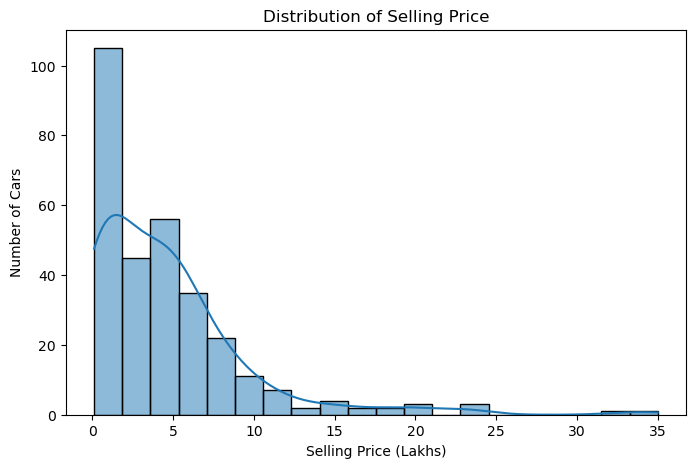

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(df['Selling_Price'], bins=20, kde=True) # bins=20 , creates 20 groups

plt.title("Distribution of Selling Price")

plt.xlabel("Selling Price (Lakhs)")

plt.ylabel("Number of Cars")

plt.show()

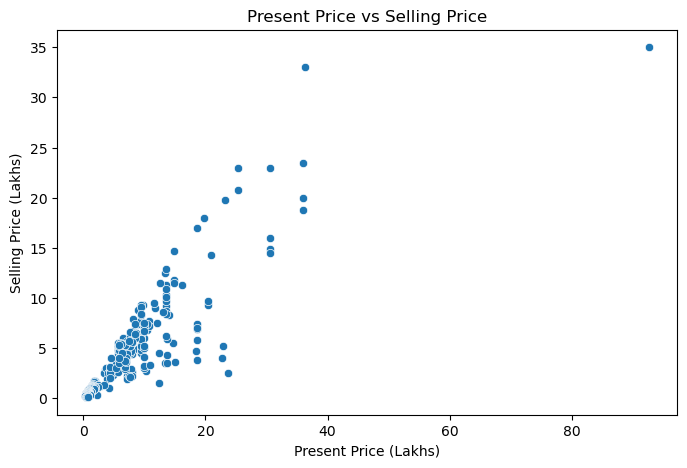

In [22]:
# Scatter Plot (Present Price vs Selling Price)

plt.figure(figsize=(8,5))

sns.scatterplot(x='Present_Price', y='Selling_Price', data=df)

plt.title("Present Price vs Selling Price")

plt.xlabel("Present Price (Lakhs)")

plt.ylabel("Selling Price (Lakhs)")

plt.show()

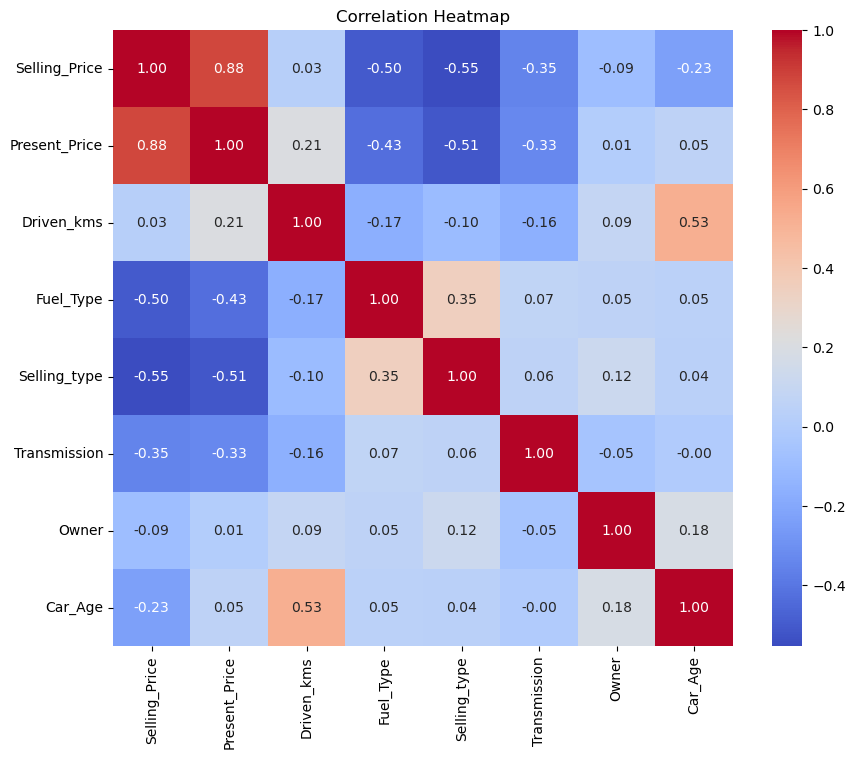

In [23]:
plt.figure(figsize=(10,8))

correlation = df.corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

In [24]:
# Phase 5: Train-Test Split

In [25]:
# Features (Input)
X = df.drop('Selling_Price', axis=1)

# Target (Output)
y = df['Selling_Price']

In [26]:
print(X.head()) #output : X contains 
print(y.head()) # output : y contains 

   Present_Price  Driven_kms  Fuel_Type  Selling_type  Transmission  Owner  \
0           5.59       27000          2             0             1      0   
1           9.54       43000          1             0             1      0   
2           9.85        6900          2             0             1      0   
3           4.15        5200          2             0             1      0   
4           6.87       42450          1             0             1      0   

   Car_Age  
0       12  
1       13  
2        9  
3       15  
4       12  
0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64


In [27]:
#split the data 

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# test_size=0.2

# This means:
# 20% of the data goes to testing.
# 80% goes to training.

In [28]:
#Verify the Split

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (239, 7)
X_test shape: (60, 7)
y_train shape: (239,)
y_test shape: (60,)


In [29]:
# Phase 6: Training your first Machine Learning Model using RandomForestRegressor

In [30]:
model = RandomForestRegressor(random_state=42) #It creates a Random Forest model., 42 just a random number

In [31]:
model.fit(X_train, y_train) #Train the Model, Builds many decision trees, Learns patterns between features and selling price., Stores those patterns for future predictions.

RandomForestRegressor(random_state=42)

In [32]:
print("Model trained successfully!") #Confirmation

Model trained successfully!


In [33]:
#there were no errors, and the model has learned from the 239 training examples.

In [34]:
###      Phase 7: Making Predictions

In [35]:
y_pred = model.predict(X_test)

# X_test contains 60 unseen cars.
# The model predicts the selling price for each one.
# The predictions are stored in y_pred.

print(y_pred) #Each number is the predicted selling price (in lakhs) for one car.


[ 9.4393  8.277   0.4401  6.868  16.564   5.3275  6.8375  1.18    7.906
  0.282  13.7384  0.2064  0.2441  0.4619  4.4835  5.3611  0.596   1.152
 21.7064  0.5603  0.572   2.5485  6.3085  2.31    5.978   9.0714  8.815
  1.1515  4.7679  5.2823  3.4385  4.4845  5.96    2.711   3.202   6.4625
  1.156   0.1566  1.1515 16.3015  6.8116  9.2668  0.9043  3.5292  0.5719
  0.2046  9.6752  4.785   3.9625  0.211   0.5972  0.3379 16.62    9.9895
  7.7435  6.8005  3.2405  3.686  10.5232  7.4265]


In [36]:
# Compare Actual vs Predicted

comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(10)

# It creates a table comparing the actual selling price with the predicted selling price.

,Actual Price,Predicted Price
0,8.99,9.4393
1,8.35,8.2770
2,0.45,0.4401
3,7.45,6.8680
4,5.25,16.5640
5,5.25,5.3275
6,5.85,6.8375
7,1.15,1.1800
8,9.25,7.9060
9,0.38,0.2820


In [37]:
# Phase 8: Model Evaluation

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1.412970000000001
Mean Squared Error (MSE): 11.15111805666667
Root Mean Squared Error (RMSE): 3.3393289829944384
R² Score: 0.5673377331701552


In [40]:
# Phase 9: Feature Importance Analysis

In [42]:
importance = model.feature_importances_
print(importance)

# model.feature_importances_ returns a number for each feature.
# The larger the value, the more important the feature.

[9.09067465e-01 1.41573172e-02 1.74661693e-03 2.02750014e-03
 4.80005128e-03 8.65094772e-06 6.81923980e-02]


In [43]:
# Match Importance with Feature Names

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance

,Feature,Importance
0,Present_Price,0.909067
1,Driven_kms,0.014157
2,Fuel_Type,0.001747
3,Selling_type,0.002028
4,Transmission,0.004800
5,Owner,0.000009
6,Car_Age,0.068192


In [44]:
# Sort the Features

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

# the most important feature appears at the top.

,Feature,Importance
0,Present_Price,0.909067
6,Car_Age,0.068192
1,Driven_kms,0.014157
4,Transmission,0.004800
3,Selling_type,0.002028
2,Fuel_Type,0.001747
5,Owner,0.000009


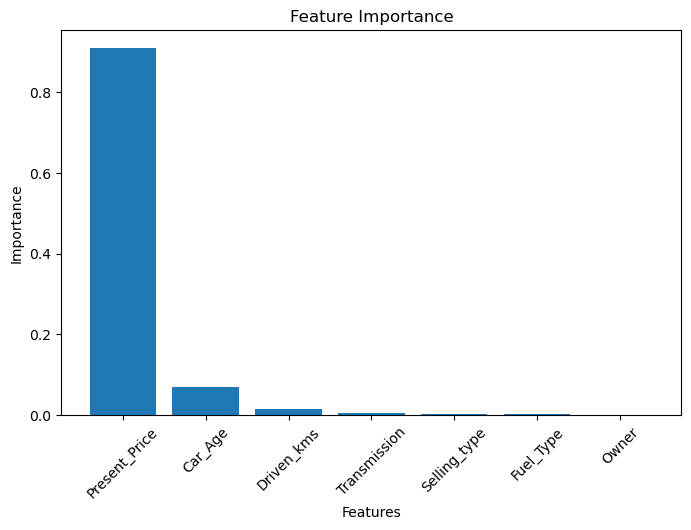

In [45]:
# Plot the Graph

plt.figure(figsize=(8,5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()

In [46]:
# Present_Price has the biggest influence.
# Owner has the least influence.

In [47]:
# Phase 10: Actual vs Predicted Price Graph

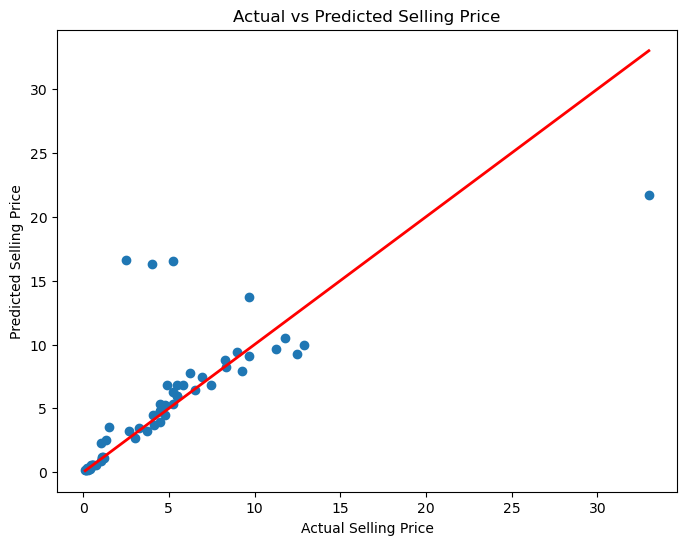

In [48]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Selling Price")

plt.ylabel("Predicted Selling Price")

plt.title("Actual vs Predicted Selling Price")

plt.show()

In [49]:
# Each dot represents one test car.
# X-axis = Actual selling price.
# Y-axis = Predicted selling price.
# The red diagonal line represents perfect predictions.

# If a point lies:
# On the red line → Perfect prediction.
# Near the red line → Good prediction.
# Far from the red line → Large prediction error.

In [50]:
# successfully completed the Car Price Prediction using Machine Learning project.